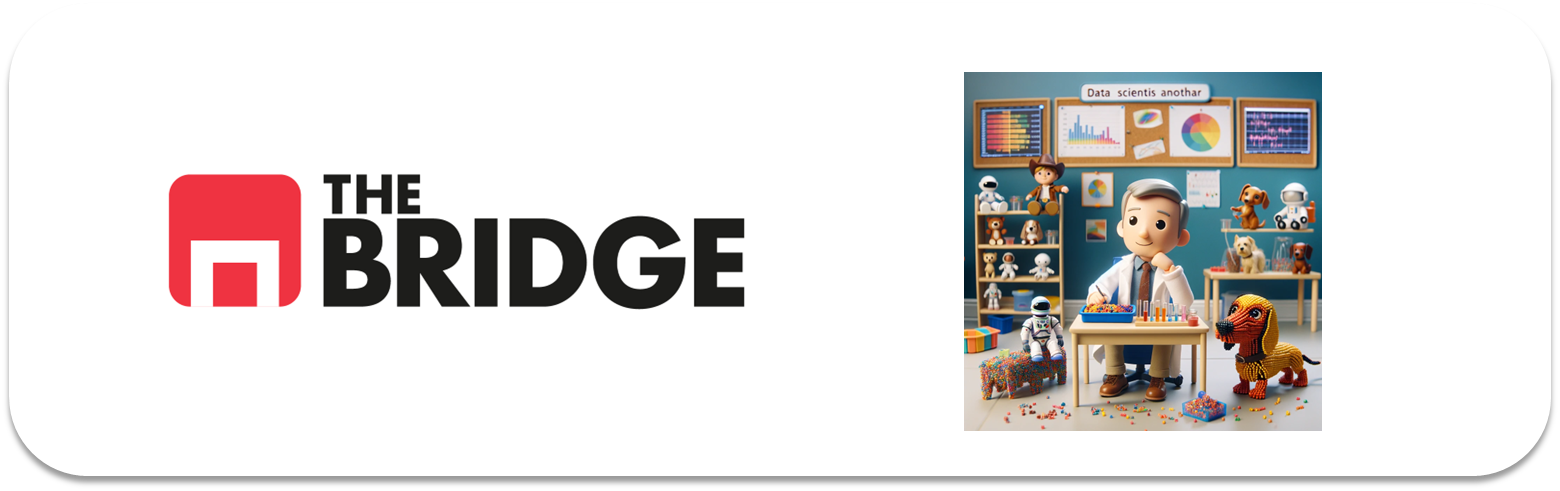

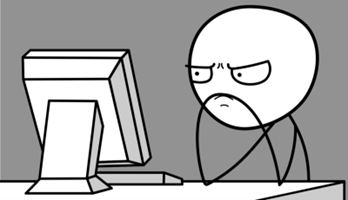

Para ejercitarte y afianzar lo aprendido sobre tendencias centrales, frecuencias, medidas de posición y rangos, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos se subirá a lo largo del sprint.

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import pinta_distribucion_categoricas, plot_multiple_boxplots


### Ejercicio 1

Carga en un dataframe los datos contenidos en la ruta "./data/admission_data.csv", muestra un parte de su contenido y la info general del mismo

In [3]:
df_admisiones = pd.read_csv("./data/admission_data.csv")
df_admisiones.head()

,Unnamed: 0,Year,Major,Gender,Admission
0,0,1973,School of Medicine,F,Rejected
1,1,1973,Department of Economics,M,Accepted
2,2,1973,Other,F,Accepted
3,3,1973,Other,M,Accepted
4,4,1973,Other,M,Rejected


In [4]:
df_admisiones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12763 entries, 0 to 12762
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  12763 non-null  int64 
 1   Year        12763 non-null  int64 
 2   Major       12763 non-null  object
 3   Gender      12763 non-null  object
 4   Admission   12763 non-null  object
dtypes: int64(2), object(3)
memory usage: 498.7+ KB


# Lets fill in the first column

In [5]:
df_admisiones.drop(columns="Unnamed: 0", inplace = True)

### Ejercicio 2

Como ya sabes este dataset queremos analizarlo para poder estudiar la posible discriminación en las admisiones de los departamentos universitarios. Analiza la variable `Year`, ¿qué crees que deberíamos hacer con esta variable?

In [6]:
# Tendencia central y medidas de posición
df_admisiones.Year.describe()

count    12763.0
mean      1973.0
std          0.0
min       1973.0
25%       1973.0
50%       1973.0
75%       1973.0
max       1973.0
Name: Year, dtype: float64

In [7]:
# Frecuencias con numeros
print("Moda:",df_admisiones.Year.mode())
print("Frecuencias Absolutas:\n", df_admisiones.Year.value_counts())
print("Frecuencias Relativas: \n", df_admisiones.Year.value_counts(normalize = True) * 100)

Moda: 0    1973
Name: Year, dtype: int64
Frecuencias Absolutas:
 Year
1973    12763
Name: count, dtype: int64
Frecuencias Relativas: 
 Year
1973    100.0
Name: proportion, dtype: float64


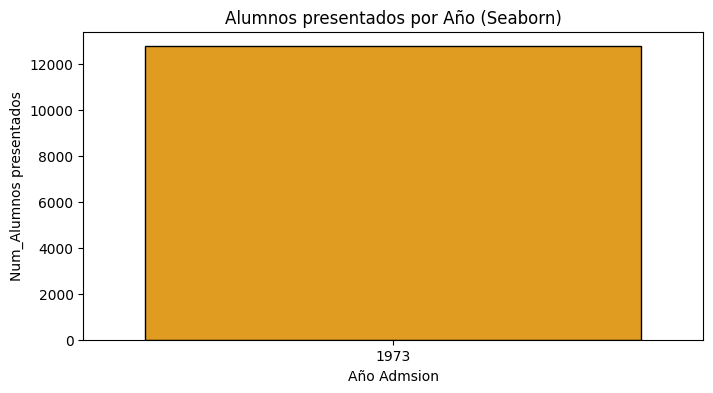

In [8]:
# Frecuencias Visualmente: como en el notebook de visualizaciones
plt.figure(figsize=(8, 4))
sns.barplot(x = df_admisiones["Year"], y = df_admisiones["Year"].value_counts(), color='orange', edgecolor='black')
plt.title('Alumnos presentados por Año (Seaborn)')
plt.xlabel('Año Admsion')
plt.ylabel('Num_Alumnos presentados')
plt.show()

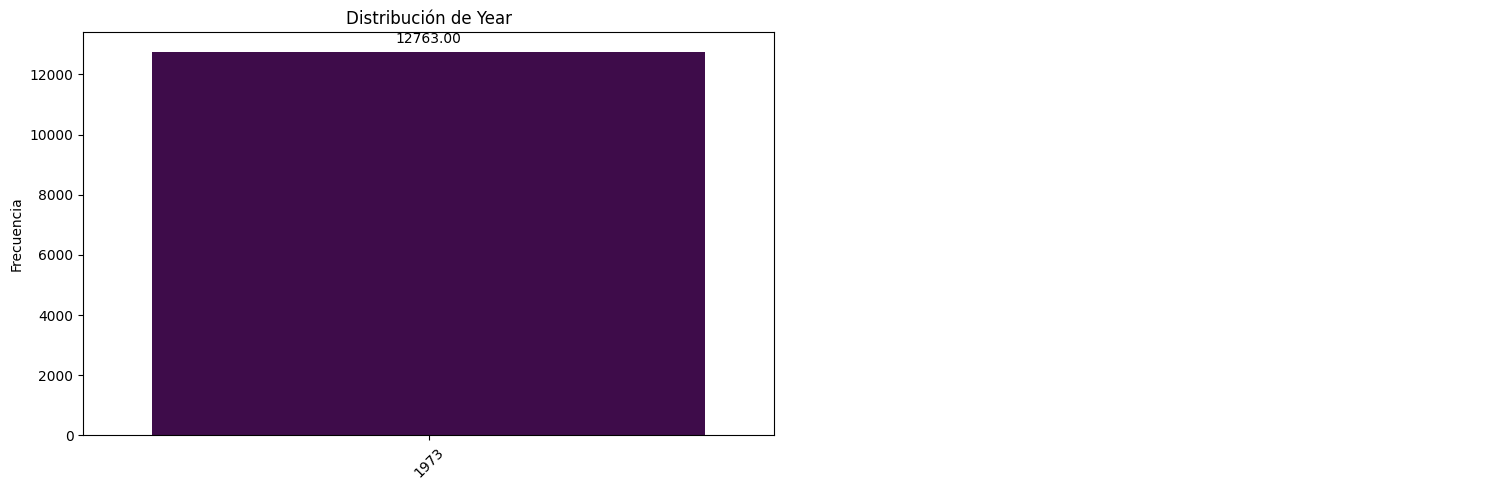

In [9]:
# Frecuencias Visualmente: utilizando la sugerida en ejercicios posteriores
pinta_distribucion_categoricas(df_admisiones, ["Year"], mostrar_valores= True)

In [ ]:
# Removing @ month column in travel dataset as it´s not fluctuating/varying , so it´s like a non.contributing factor.

In [ ]:
df_admisiones.drop(columns= "Year", inplace= True)

### Ejercicio 3

Analiza ahora la columna `Major`, obtén las frecuencias absolutas y relativas de forma numérica y de forma gráfica. Puedes emplear las funciones del notebook de visualizaciones del repo o bien la función `pinta_distribucion_categoricas` del módulo `bootcampviztools` y que hemos usado en el workout. (Tiene un argumento `relativa` para mostrar las frecuencias relativas y otro `mostrar_valores` para enseñar las etiquetas de los valores).

In [ ]:
# Let´s create a function that returns the absolute and relative frequencies from a column in a dataframe and start analyzing now.

def frecuencias(df, columna_categorica, porcentaje = True):
    frec_abs = df[columna_categorica].value_counts() # Values_counts() gives the frequencies
    frec_rel = df[columna_categorica].value_counts(normalize=True) * (100 if porcentaje else 1)  # Enabling "normalise" parameter gives us a relative ratio of 1, the percentage allows the conversion to a ratio of c

    #  DataFrame con both frecuenceis
    frec_df = pd.DataFrame({'Frecuencia Absoluta': frec_abs, 'Frecuencia Relativa': frec_rel})

    return frec_df

In [13]:
# Valores numéricos:
df_frecuencias = frecuencias(df_admisiones, "Major")
df_frecuencias

,Frecuencia Absoluta,Frecuencia Relativa
Major,,
Other,7924,62.085717
Department of Physics and Astronomy,1246,9.762595
School of Medicine,918,7.192666
Department of Mechanical Engineering,792,6.205438
Department of Psychology,714,5.594296
Department of Economics,585,4.583562
School of Political Science and International Relations,584,4.575727


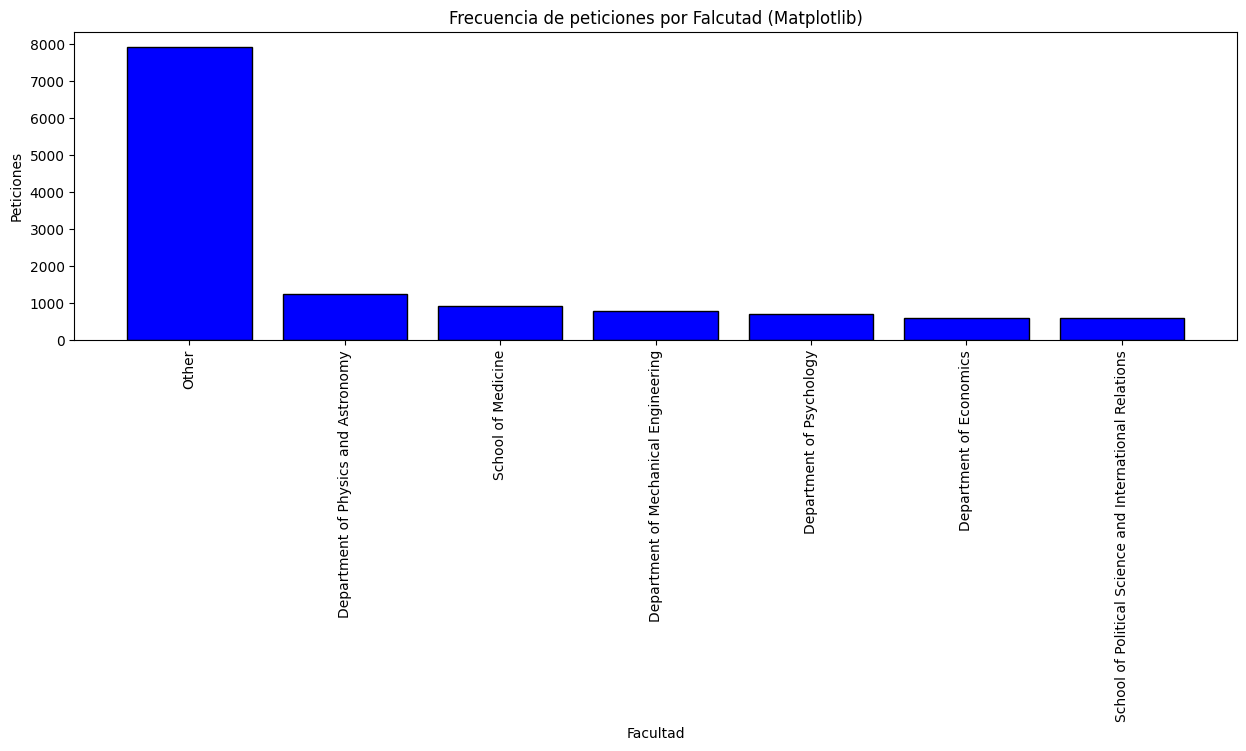

In [14]:
# Visually, frecuencias absolutas: Using the funciones of matplotlib 
plt.figure(figsize=(15, 4))
plt.bar(df_frecuencias.index, df_frecuencias["Frecuencia Absoluta"], color='blue', edgecolor='black') # Primero las etiquetas (en este caso el nombre de los departamentos que considero), luego los valores
plt.title('Frecuencia de peticiones por Falcutad (Matplotlib)')
plt.xlabel('Facultad')
plt.ylabel('Peticiones')
plt.xticks(rotation = 90) # Añadido para que los nombres se puedan ver
plt.show()

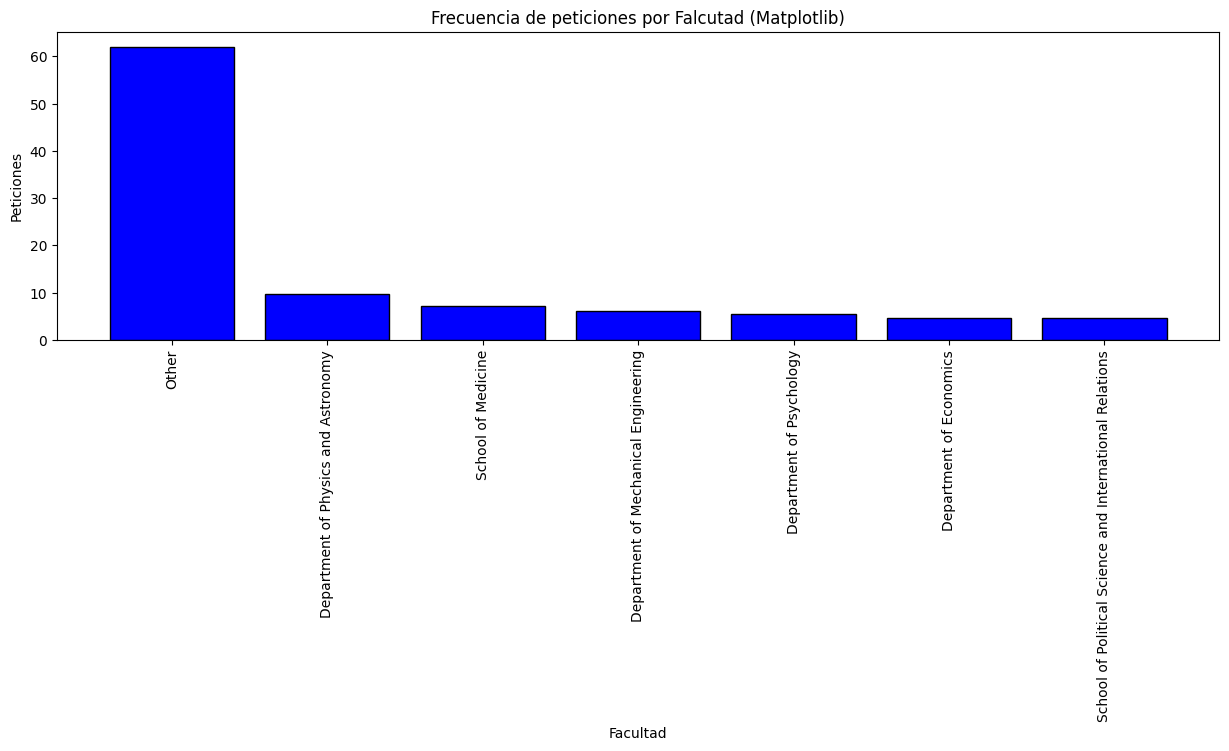

In [15]:
# Visually, relative frequencies: Using the funciones of matplotlib from the notebook of visualizacions
plt.figure(figsize=(15, 4))
plt.bar(df_frecuencias.index, df_frecuencias["Frecuencia Relativa"], color='blue', edgecolor='black') 
plt.title('Frecuencia de peticiones por Falcutad (Matplotlib)')
plt.xlabel('Facultad')
plt.ylabel('Peticiones')
plt.xticks(rotation = 90) # Añadido para que los nombres se puedan ver
plt.show()

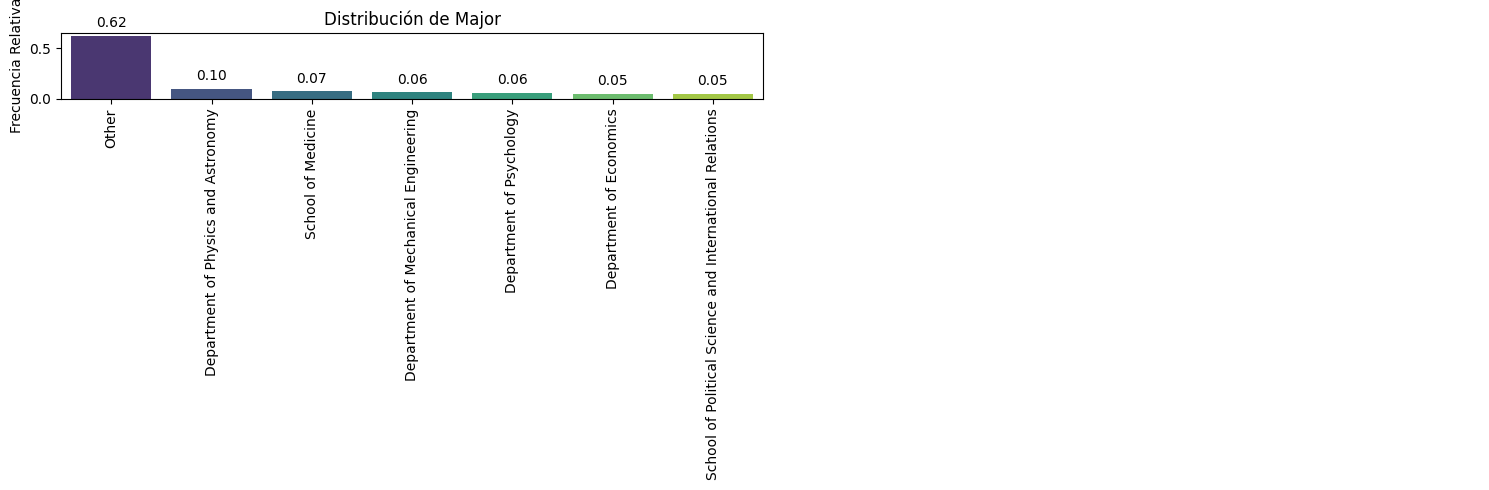

In [16]:
pinta_distribucion_categoricas(df_admisiones, ["Major"], relativa= True, mostrar_valores= True, giro = 90) # Relative frequencies using functions 

### Ejercicio 4

¿Qué puedes comentar de los datos anteriores?

As per our findings:
1. The dataset clearly shows that the departments listed do not account for the majority of admissions (which are in the ‘Others’ category, with a clear majority (62-38)). 
1. For practical administrative or academic analysis, this "Other" category would likely need to be broken down further to identify which specific smaller faculties are driving the bulk of the requests.
1. Out of the clearly identified departments, Physics and Astronomy is the most significant, though it still only represents a small fraction (1/10th) of the total.
1. There is very little variation between the remaining departments. The difference between Medicine (7%) and Political Science (5%) is only 2 percentage points, suggesting these core departments have fairly equal representation in this dataset.

Because 62% is grouped as "Other," any decisions based only on the named departments would be ignoring the majority of the population. This chart is a great "big picture" view, but it highlights a need for more granular data if you need to target specific niche groups.


### Ejercicio 5

Analiza ahora la columna `Gender`, obtén las frecuencias absolutas y relativas de forma numérica y de forma gráfica. 

*Since we have already found the absolute and relative frequencies, it should help us here. Now, we generate graphical view.

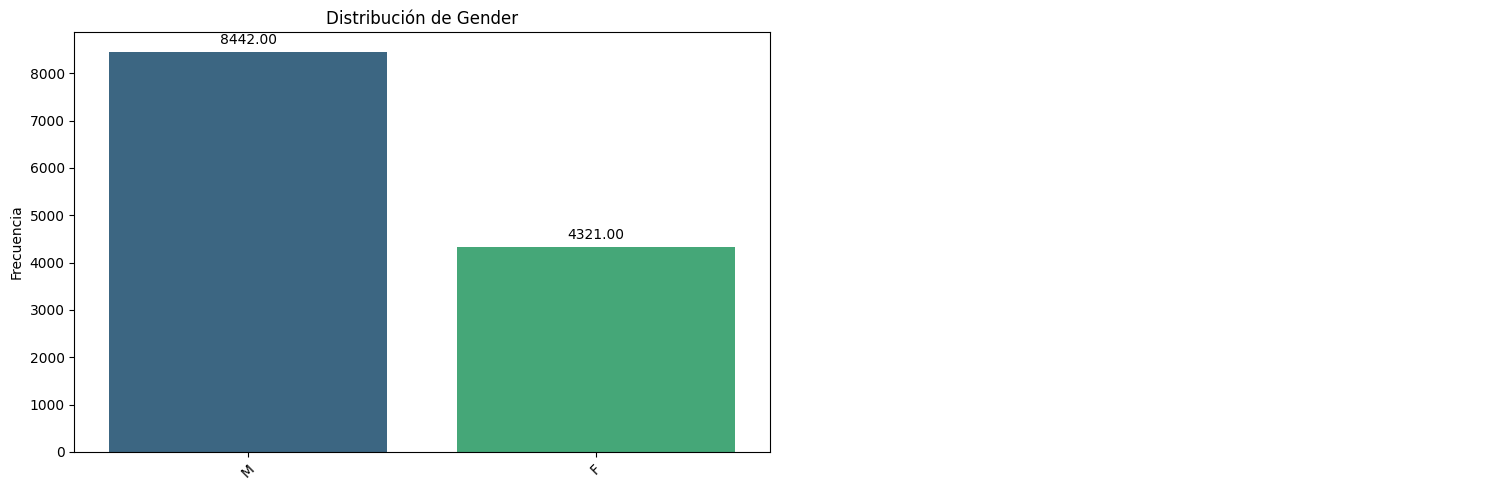

In [17]:
pinta_distribucion_categoricas(df_admisiones, ["Gender"], relativa= False, mostrar_valores= True, giro = 45)

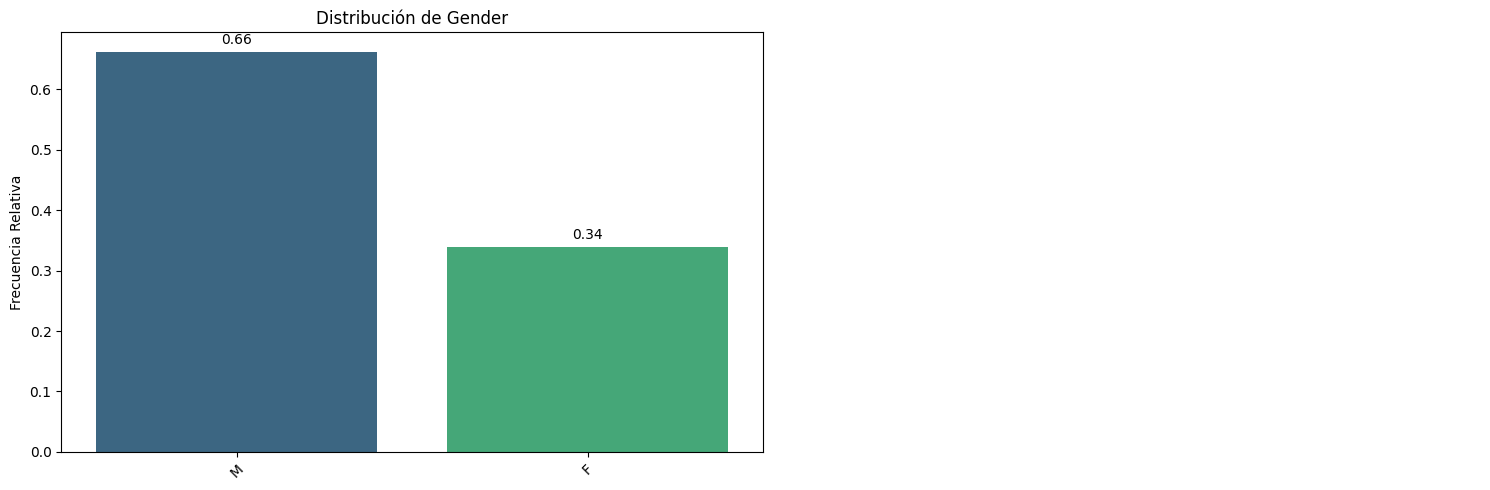

In [18]:
pinta_distribucion_categoricas(df_admisiones, ["Gender"], relativa= True, mostrar_valores= True, giro = 45)

### Ejercicio 6

¿Qué puedes comentar de los datos anteriores?

1. There is a clear majority of apps classified as male (66-34) (we assume that M stands for male)

1. Apps classified as ‘male’ account for 66% of the total

1. Apps classified as ‘female’ account for 34% of the total

### Ejercicio 7

Finalmente analiza, la columna `Admission`, obtén las frecuencias absolutas y relativas de forma numérica y de forma gráfica. 

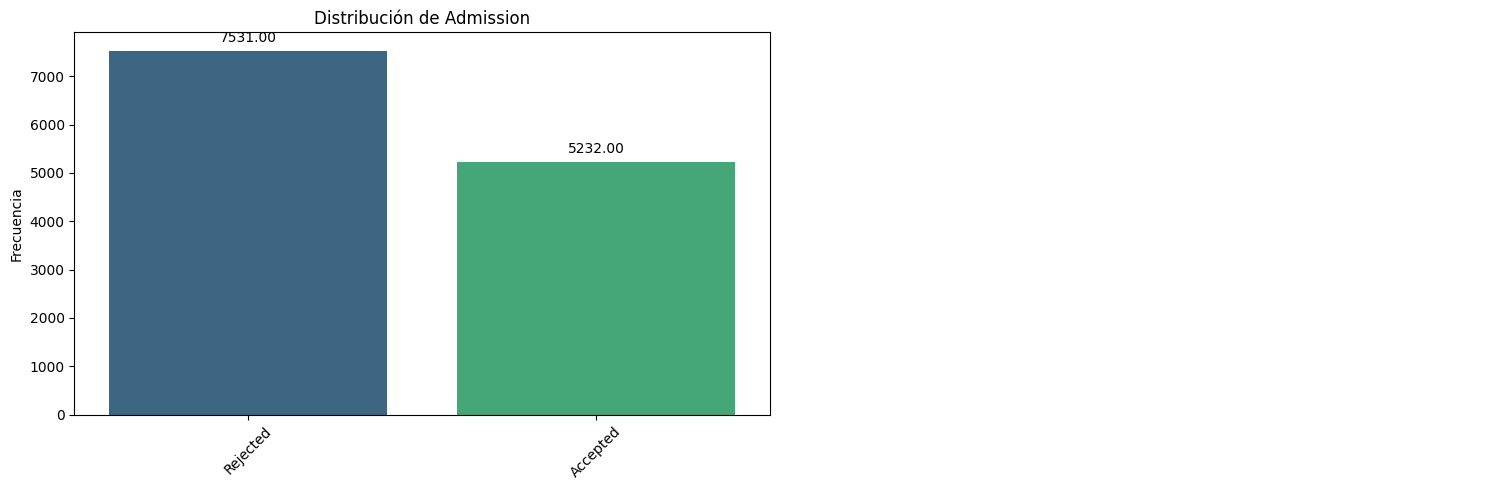

In [19]:
pinta_distribucion_categoricas(df_admisiones, ["Admission"], relativa= False, mostrar_valores= True, giro = 45)

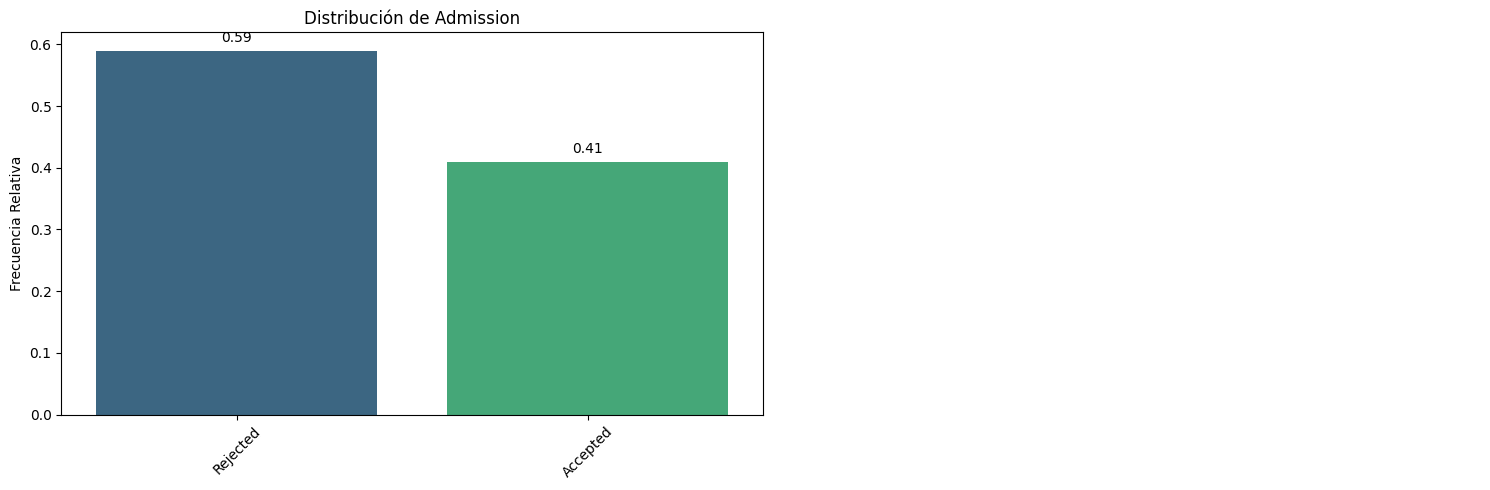

In [20]:
pinta_distribucion_categoricas(df_admisiones, ["Admission"], relativa= True, mostrar_valores= True, giro = 45)

### Ejercicio 8

¿Qué puedes comentar de los datos anteriores?

* Approx. 59% of all applicants were rejected.
* Approx. 41% of applicants were accepted.

From this dataset, we conclude that for the year 1973, with an acceptance rate of 41%, the admission process appears to be moderately selective.

Looking at this alongside your previous charts (where 62% of applicants are in "Other" majors), it would be interesting to see if certain majors—like Physics and Astronomy—have a significantly higher or lower acceptance rate than this 41% average.


1. Individual departments account for 38% of admission applications, with the remaining 62% coming from other sources.
1.  With a higher number and percentage of male applications than female ones (66% to 34%) out of 12,763 applications.
1. Rejecting more applicants than it accepts (59%–41%).

The majority of candidates do not receive an offer of admission.


### Ejercicio 9

Carga en un dataframe los datos contenidos en la ruta "./data/tips.csv", muestra un parte de su contenido y la info general del mismo

In [21]:

df_tips = pd.read_csv("./data/tips.csv")
df_tips.head()

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4


In [22]:
df_tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  244 non-null    int64  
 1   total_bill  244 non-null    float64
 2   tip         244 non-null    float64
 3   sex         244 non-null    object 
 4   smoker      244 non-null    object 
 5   day         244 non-null    object 
 6   time        244 non-null    object 
 7   size        244 non-null    int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 15.4+ KB


In [24]:
df_tips.drop(columns= "Unnamed: 0", inplace = True) # deleting this column due to it´s duplicacy

KeyError: "['Unnamed: 0'] not found in axis"

### Ejercicio 10

Vamos a analizar las medidas de tendencia central (media, mediana), las de posición (los cuartiles) y los rangos de las variables numéricas del dataset. Muestra esos valores para todas las variables numéricas del dataset.

In [ ]:
df_tips.describe()

### Ejercicio 11

Para completar el análisis incial de las variables numéricas, muestra el diagrama de caja (*boxplot*) para cada una de las variables numéricas del dataset. ¿Qué puedes decir de ellas? (Puedes emplear las funciones incluidas en el notebook de visualizaciones sencillas o la función `plot_multiple_boxplots` de `bootcampviztools`, y que hemos empleado en el workout)

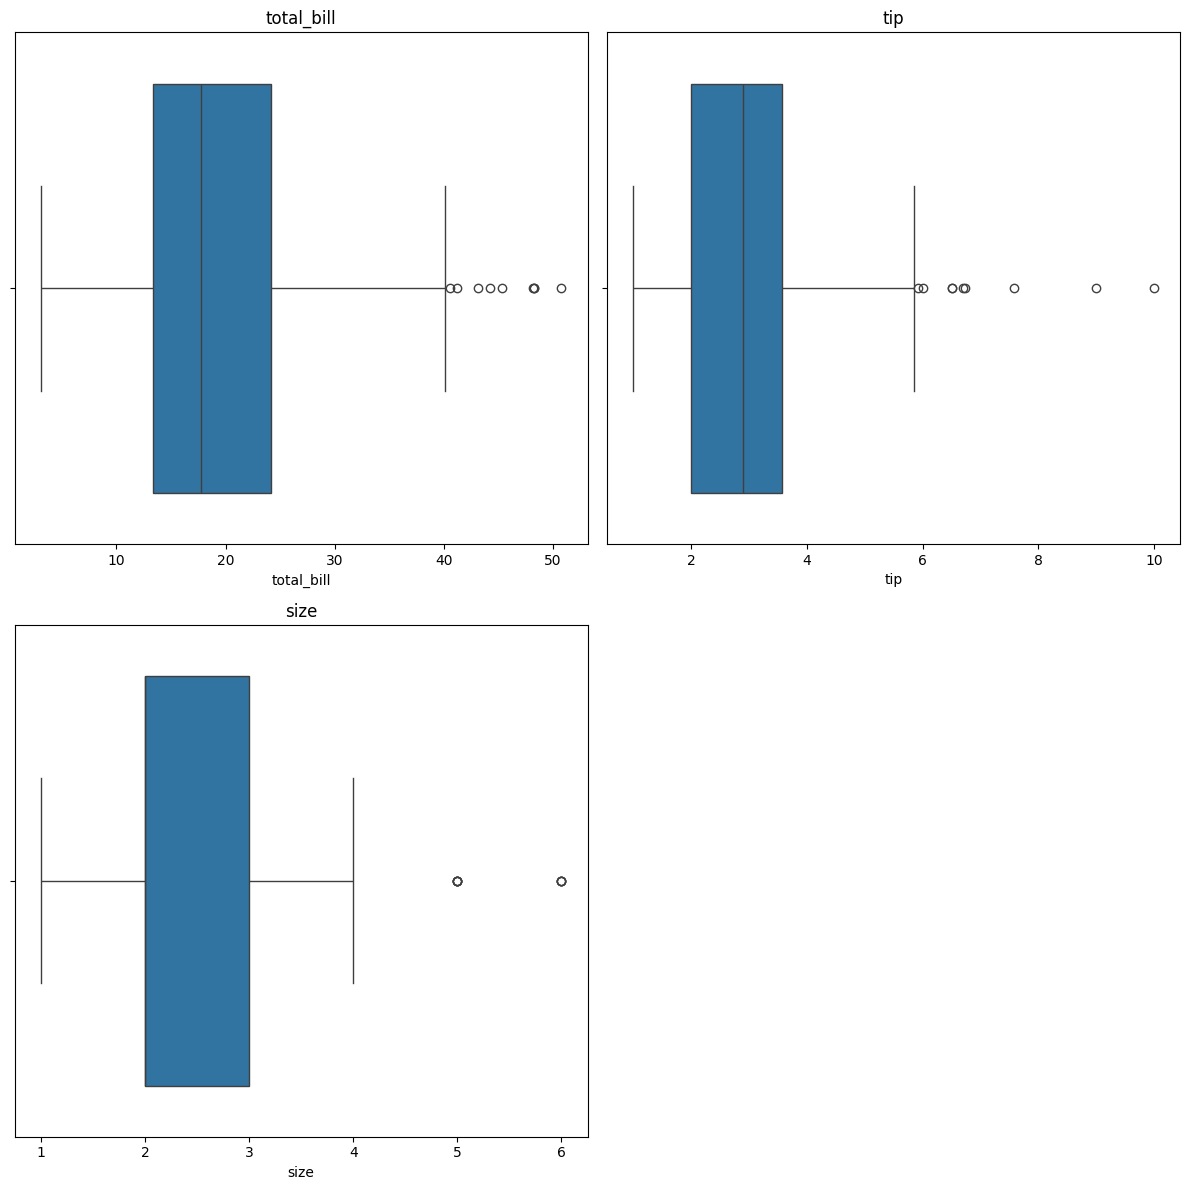

In [25]:
# Using Function
plot_multiple_boxplots(df_tips,["total_bill","tip","size"])

1. ‘total_bill’ has a mean of 19.78, a median of 17.8, a range between 3.07 and 50, and from the box plot I can see that there is some dispersion, though not excessive (visually);
   we could consider some values to be outliers and there is some symmetry around the median, although closer to the first quartile than to the third quartile, There is more dispersion in the values above the median.
1. ‘tip’ has a mean of 3 (2.99), a median of 2.9, and a range of 1.56. Looking at the box plot, we can see (from the width of the box) 
   a certain concentration of values, some symmetry around the median (though this is closer to Q3 than to Q1), and there is more dispersion in the lower values than in the higher ones. We might also consider looking at some outliers.
1. ‘size’ has a mean of 2.56 and a median of 2 (which perhaps represents it better), but looking at its range of values,
   it is better to supplement the analysis with a frequency analysis (that is the advantage of discrete numerical data).   
1. Sticking with the median as the best representation of size rather than the mean.
1. Means references needs to be supplemented with a dispersion analysis and histograms,we could bear in mind—to check if tips are 1/7th of the
   bills (i.e. roughly 14% of the total). Is that 14% a very central value/ giving roughly 14% as a tip is a cultural norm?

1. Counting the above information, we need the dispersion/distribution analysis to answer questions like:
    the percentage hold true for the outliers? Do the outliers correspond from one set to the other

### Ejercicio Extra #1:

Muestra las frecuencias absolutas y relativas de las variables categóricas del dataset. ¿Qué podrías destacar?

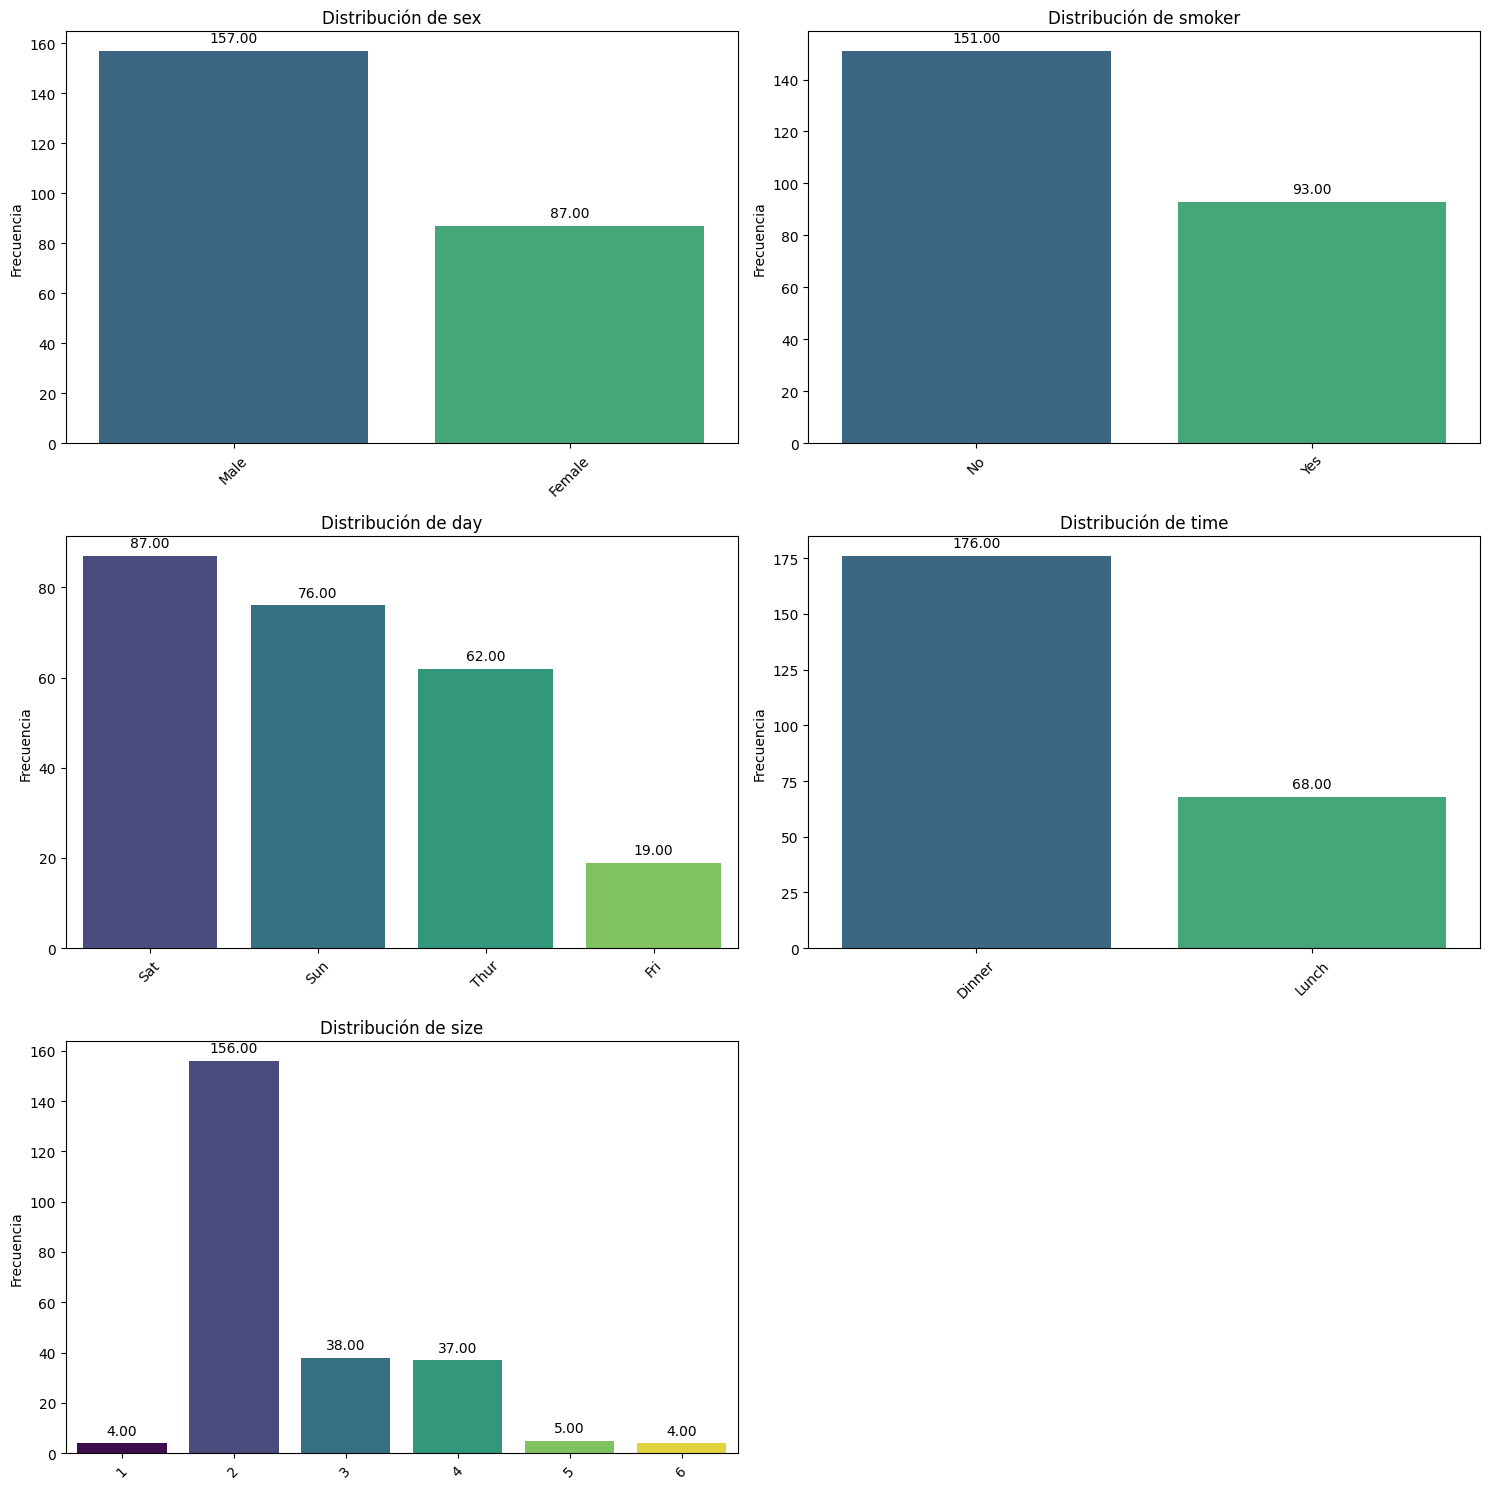

In [26]:
pinta_distribucion_categoricas(df_tips, ["sex","smoker","day","time","size"], mostrar_valores= True)

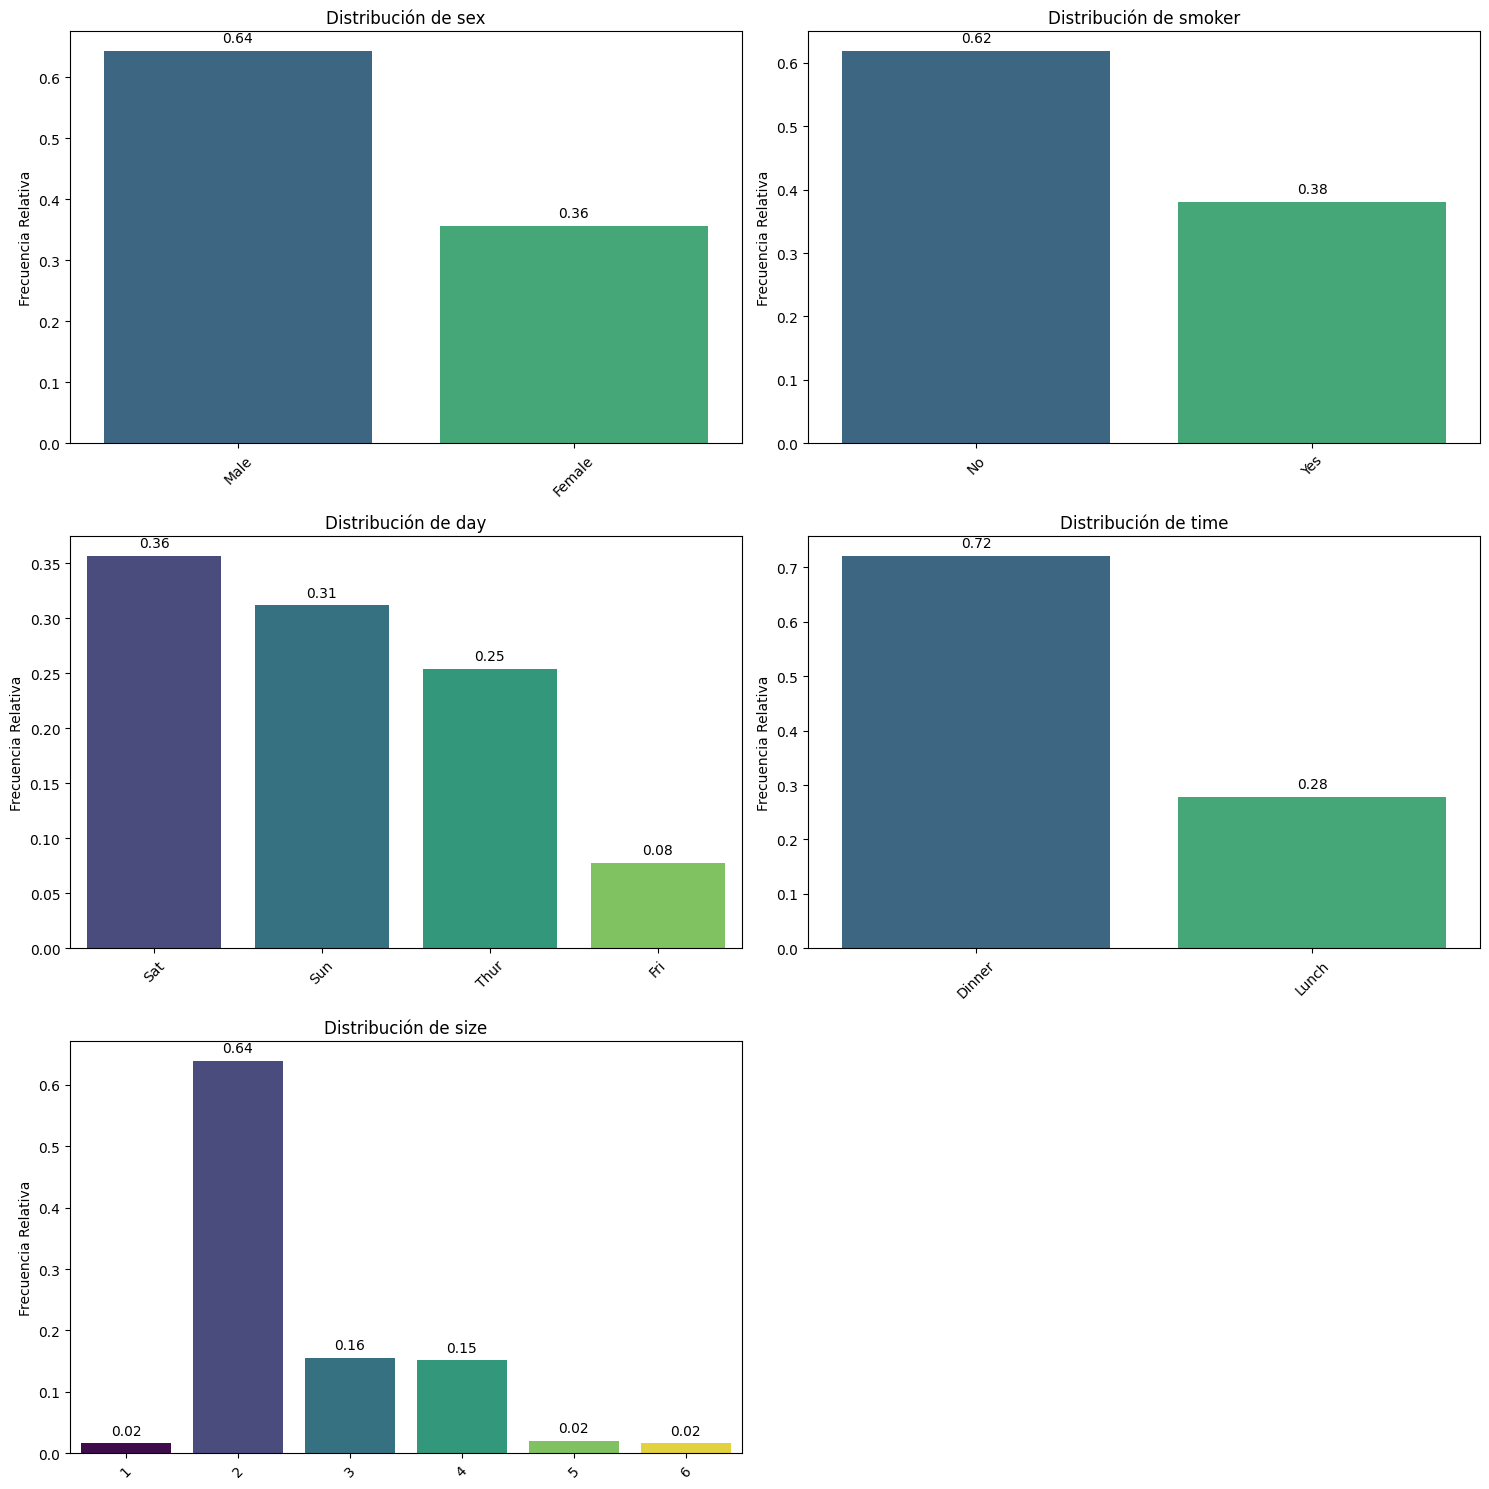

In [27]:
pinta_distribucion_categoricas(df_tips, ["sex","smoker","day","time","size"], mostrar_valores= True, relativa = True)

* This dataset contains more non-smokers than smokers (62%–38%).
* The frequency distribution of the ‘sex’ variable also shows a skew towards male customers (64%–36%)

* It is a dataset predominantly comprising weekend data (67%–33%)

* It is a dataset predominantly comprising lunches rather than dinners (72%–28%)

* To conclude and reaffirm my decision to use the value 2 as the representative group size (64%–36%). This raises the question: if the dataset is organised by groups, then to whom do the variables ‘sex’ and ‘gender’ refer? To the person paying? (I would need to ask this of the data source)

### Ejercicio Extra #2:

Carga en un dataframe el dataset de los seguros que tanto conoces ya ("./data/Marketing-Customer-Analysis.csv") y analiza cual es el perfil típico del cliente de la compañía a partir de las variables categóricas siguientes: `education, state, employmentstatus, gender, marital_status, vehicle_class, vehicle_size`. (Nota: en el workout lo hicimos a partir de las modas de dichos valores, pero no es la forma "precisa" de hacerlo, piensa en la "moda" sí pero de la combinación de valores)


In [28]:
df_seguros = pd.read_csv("./data/Marketing-Customer-Analysis.csv")
perfilado = ["education", "state", "employmentstatus", "gender", "marital_status", "vehicle_class", "vehicle_size"]
df_seguros.groupby(perfilado)["customer"].count().nlargest(5)

education  state       employmentstatus  gender  marital_status  vehicle_class  vehicle_size
College    California  Employed          F       Married         Four-Door Car  Medsize         79
           Oregon      Employed          F       Married         Four-Door Car  Medsize         78
Bachelor   California  Employed          F       Married         Four-Door Car  Medsize         76
College    California  Employed          M       Married         Four-Door Car  Medsize         75
Bachelor   California  Employed          M       Married         Four-Door Car  Medsize         72
Name: customer, dtype: int64

* we need to group the data by all possible values and calculate the mode for each group; another issue is that, once again, there are many values that are close to the mode.

* In this case, our typical customer closely resembles the profile derived from the individual modes: a working woman from California or Oregon, with an education level between college and bachelor’s degree, married, and driving a four-door saloon car.